In [31]:
# PROJECT OVERVIEW

print("""
╔══════════════════════════════════════════════════════════════════════╗
║           QUANTITATIVE PORTFOLIO ANALYTICS DASHBOARD                 ║
║                                                                      ║
║  Author  : Prince Raj                                                ║
║  College : IIT Jodhpur | B.Tech Chemical Engineering                 ║
║  Date    : June 2026                                                 ║
║  Tools   : Python, Pandas, NumPy, SciPy, Plotly, yfinance            ║
╚══════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📌 PROJECT OBJECTIVE
━━━━━━━━━━━━━━━━━━━━
Build a quantitative portfolio analytics dashboard to evaluate stock
performance, risk metrics, and optimized allocations using Python —
demonstrating the analytical and quantitative skills required for
market-making and trading roles.

📌 PROBLEM STATEMENT
━━━━━━━━━━━━━━━━━━━━
Retail and institutional investors need data-driven tools to:
  1. Track portfolio performance against market benchmarks
  2. Quantify risk using industry-standard metrics
  3. Optimize asset allocation using Modern Portfolio Theory
  4. Identify correlation patterns for better diversification

This project builds an end-to-end portfolio analytics system that
addresses all four requirements using real market data.

📌 METHODOLOGY
 ━━━━━━━━━━━━━━
  Step 1 → Data Collection      : Real-time NSE data via Yahoo Finance API
  Step 2 → Portfolio Construction: Weighted portfolio of 5 large-cap stocks
  Step 3 → Performance Analysis  : Returns, Sharpe, Sortino, VaR, Drawdown
  Step 4 → Benchmark Comparison  : Portfolio vs Nifty 50 Index
  Step 5 → Correlation Analysis  : Inter-stock correlation for diversification
  Step 6 → Portfolio Optimization: Markowitz Mean-Variance Optimization
  Step 7 → Insights & Reporting  : Key findings and recommendations

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


╔══════════════════════════════════════════════════════════════════════╗
║           QUANTITATIVE PORTFOLIO ANALYTICS DASHBOARD                 ║
║                                                                      ║
║  Author  : Prince Raj                                                ║
║  College : IIT Jodhpur | B.Tech Chemical Engineering                 ║
║  Date    : Jun 2026                                                  ║
║  Tools   : Python, Pandas, NumPy, SciPy, Plotly, yfinance            ║
╚══════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📌 PROJECT OBJECTIVE
━━━━━━━━━━━━━━━━━━━━
Build a quantitative portfolio analytics dashboard to evaluate stock 
performance, risk metrics, and optimized allocations using Python — 
demonstrating the analytical and quantitative skills required for 
market-making and trading roles.

📌 PROBLEM STATEMENT
━━━━━━━━━━━━━━━━━━━━
Retail and instituti

In [32]:
# INSTALL LIBRARIES


!pip install yfinance plotly scipy seaborn -q
print("All libraries installed!")

All libraries installed!


In [35]:
# IMPORTS
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import seaborn as sns
from scipy.optimize import minimize
from datetime import datetime
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

print("All imports done!")

All imports done!


In [36]:
# DEFINE PORTFOLIO & FETCH DATA


print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 SECTION 1: DATA COLLECTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

# CONFIGURE YOUR PORTFOLIO HERE
portfolio_stocks = {
    "RELIANCE.NS": {"shares": 10, "buy_price": 2500},
    "TCS.NS":      {"shares": 5,  "buy_price": 3800},
    "INFY.NS":     {"shares": 15, "buy_price": 1600},
    "HDFCBANK.NS": {"shares": 8,  "buy_price": 1650},
    "ITC.NS":      {"shares": 20, "buy_price": 450},
}

tickers = list(portfolio_stocks.keys())
PERIOD = "1y"  # Change to "6mo", "2y", "5y" as needed

# Fetch closing prices
print("Fetching stock data...")
raw_prices = yf.download(tickers, period=PERIOD)

# Handle MultiIndex columns from newer yfinance
if isinstance(raw_prices.columns, pd.MultiIndex):
    prices = raw_prices["Close"].copy()
else:
    prices = raw_prices[["Close"]].copy()

prices = prices.dropna()

# Flatten column names if they have extra levels
if isinstance(prices.columns, pd.MultiIndex):
    prices.columns = prices.columns.get_level_values(0)

# Fetch benchmark (Nifty 50)
print("Fetching Nifty 50 data...")
raw_bench = yf.download("^NSEI", period=PERIOD)

if isinstance(raw_bench.columns, pd.MultiIndex):
    benchmark = raw_bench["Close"].squeeze()
else:
    benchmark = raw_bench["Close"]

# Ensure benchmark is a Series
if isinstance(benchmark, pd.DataFrame):
    benchmark = benchmark.squeeze()

benchmark = benchmark.dropna()

print(f"\nData fetched! {len(prices)} trading days")
print(f"Period: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"Stocks: {[t.replace('.NS','') for t in tickers]}")
print(f"Benchmark: Nifty 50")
prices.tail()

[                       0%                       ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 SECTION 1: DATA COLLECTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Fetching stock data...


[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed

Fetching Nifty 50 data...

Data fetched! 248 trading days
Period: 2025-03-05 to 2026-03-05
Stocks: ['RELIANCE', 'TCS', 'INFY', 'HDFCBANK', 'ITC']
Benchmark: Nifty 50


Ticker,HDFCBANK.NS,INFY.NS,ITC.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2026-02-26,898.599976,1289.099976,318.299988,1406.800049,2647.699951
2026-02-27,887.750000,1300.099976,313.600006,1393.900024,2637.399902
2026-03-02,879.400024,1288.900024,314.899994,1358.000000,2613.500000
2026-03-04,868.650024,1307.400024,311.950012,1345.000000,2587.800049
2026-03-05,873.299988,1294.699951,310.250000,1380.699951,2548.100098


In [37]:

# PORTFOLIO CONSTRUCTION RATIONALE


print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 SECTION 2: PORTFOLIO CONSTRUCTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# STOCK SELECTION STRATEGY
━━━━━━━━━━━━━━━━━━━━━━━━━━━
The portfolio is constructed using 5 large-cap Indian equities selected
for SECTOR DIVERSIFICATION across major Nifty 50 sectors:

┌──────────────┬──────────────┬──────────┬────────────────────────────┐
│ Stock        │ Sector       │ Shares   │ Selection Rationale        │
├──────────────┼──────────────┼──────────┼────────────────────────────┤
│ RELIANCE     │ Energy/Congl │ 10       │ Largest Indian company,    │
│              │              │          │ diversified revenue streams │
├──────────────┼──────────────┼──────────┼────────────────────────────┤
│ TCS          │ IT Services  │ 5        │ Global IT leader, stable   │
│              │              │          │ USD revenue, defensive     │
├──────────────┼──────────────┼──────────┼────────────────────────────┤
│ INFOSYS      │ IT Services  │ 15       │ Growth-oriented IT,        │
│              │              │          │ strong digital revenue     │
├──────────────┼──────────────┼──────────┼────────────────────────────┤
│ HDFC BANK    │ Banking      │ 8        │ Largest private bank,      │
│              │              │          │ proxy for India's growth   │
├──────────────┼──────────────┼──────────┼────────────────────────────┤
│ ITC          │ FMCG/Tobacco │ 20       │ Defensive stock, high      │
│              │              │          │ dividend yield, low beta   │
└──────────────┴──────────────┴──────────┴────────────────────────────┘

# SECTOR ALLOCATION:
   • Technology  : 2 stocks (TCS + Infosys) → Growth + USD hedge
   • Energy      : 1 stock  (Reliance)      → Conglomerate exposure
   • Banking     : 1 stock  (HDFC Bank)     → Financial sector proxy
   • FMCG        : 1 stock  (ITC)           → Defensive, low volatility

# DIVERSIFICATION LOGIC:
   • Mix of cyclical (Banking, Energy) and defensive (FMCG, IT) sectors
   • Exposure to both domestic consumption and global revenue
   • All stocks are Nifty 50 constituents → high liquidity
""")

# Sector mapping
sector_map = {
    "RELIANCE.NS": "Energy/Conglomerate",
    "TCS.NS": "IT Services",
    "INFY.NS": "IT Services",
    "HDFCBANK.NS": "Banking & Finance",
    "ITC.NS": "FMCG"
}


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 SECTION 2: PORTFOLIO CONSTRUCTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# STOCK SELECTION STRATEGY
━━━━━━━━━━━━━━━━━━━━━━━━━━━
The portfolio is constructed using 5 large-cap Indian equities selected 
for SECTOR DIVERSIFICATION across major Nifty 50 sectors:

┌──────────────┬──────────────┬──────────┬────────────────────────────┐
│ Stock        │ Sector       │ Shares   │ Selection Rationale        │
├──────────────┼──────────────┼──────────┼────────────────────────────┤
│ RELIANCE     │ Energy/Congl │ 10       │ Largest Indian company,    │
│              │              │          │ diversified revenue streams │
├──────────────┼──────────────┼──────────┼────────────────────────────┤
│ TCS          │ IT Services  │ 5        │ Global IT leader, stable   │
│              │              │          │ USD revenue, defensive     │
├──────────────┼──────────────┼──────────┼──────────────

In [38]:
# PORTFOLIO SUMMARY & P&L


print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 SECTION 3: PORTFOLIO OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

# Use float() to ensure scalar values
current_prices = {ticker: float(prices[ticker].iloc[-1]) for ticker in tickers}

# Build summary table
rows = []
total_invested = 0
total_current = 0

for ticker, info in portfolio_stocks.items():
    curr_price = current_prices[ticker]
    invested = info["shares"] * info["buy_price"]
    current_val = info["shares"] * curr_price
    pnl = current_val - invested
    pnl_pct = (pnl / invested) * 100

    total_invested += invested
    total_current += current_val

    rows.append({
        "Stock": ticker.replace(".NS", ""),
        "Sector": sector_map.get(ticker, "Other"),
        "Shares": info["shares"],
        "Buy Price (₹)": round(info["buy_price"], 2),
        "Current Price (₹)": round(curr_price, 2),
        "Invested (₹)": round(invested, 2),
        "Current Value (₹)": round(current_val, 2),
        "P&L (₹)": round(pnl, 2),
        "P&L (%)": round(pnl_pct, 2),
    })

summary = pd.DataFrame(rows)

total_pnl = total_current - total_invested
total_pnl_pct = (total_pnl / total_invested) * 100

print("📊 HOLDINGS TABLE")
print("─" * 70)
display(summary)

print(f"\n{'─' * 50}")
print(f"   Total Invested  : ₹{total_invested:>12,.2f}")
print(f"   Current Value   : ₹{total_current:>12,.2f}")
pnl_emoji = '🟢' if float(total_pnl) >= 0 else '🔴'
print(f"  {pnl_emoji} Total P&L      : ₹{float(total_pnl):>12,.2f} ({float(total_pnl_pct):+.2f}%)")
print(f"{'─' * 50}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 SECTION 3: PORTFOLIO OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📊 HOLDINGS TABLE
──────────────────────────────────────────────────────────────────────


,Stock,Sector,Shares,Buy Price (₹),Current Price (₹),Invested (₹),Current Value (₹),P&L (₹),P&L (%)
0,RELIANCE,Energy/Conglomerate,10,2500,1380.70,25000,13807.0,-11193.0,-44.77
1,TCS,IT Services,5,3800,2548.10,19000,12740.5,-6259.5,-32.94
2,INFY,IT Services,15,1600,1294.70,24000,19420.5,-4579.5,-19.08
3,HDFCBANK,Banking & Finance,8,1650,873.30,13200,6986.4,-6213.6,-47.07
4,ITC,FMCG,20,450,310.25,9000,6205.0,-2795.0,-31.06



──────────────────────────────────────────────────
   Total Invested  : ₹   90,200.00
   Current Value   : ₹   59,159.40
  🔴 Total P&L      : ₹  -31,040.60 (-34.41%)
──────────────────────────────────────────────────


In [39]:
# CALCULATE WEIGHTS, RETURNS & BENCHMARK SETUP


print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 BENCHMARK SELECTION
━━━━━━━━━━━━━━━━━━━━━━

Benchmark: NIFTY 50 INDEX (^NSEI)

WHY NIFTY 50?
   • Represents the top 50 companies on NSE by market capitalization
   • Standard benchmark for Indian equity portfolios
   • All 5 portfolio stocks are Nifty 50 constituents
   • Allows direct comparison: "Did our stock picking beat the market?"

EVALUATION FRAMEWORK:
   • Portfolio Return > Nifty 50 → Stock selection added value (+ Alpha)
   • Portfolio Sharpe > Nifty 50 Sharpe → Better risk-adjusted returns
   • Beta > 1 → Portfolio more volatile than market
   • Beta < 1 → Portfolio less volatile than market

RISK-FREE RATE: 7.0% (India 10Y Govt Bond Yield, approximate)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

# ─── Calculate portfolio weights based on current market value ───
market_values = {t: portfolio_stocks[t]["shares"] * float(current_prices[t]) for t in tickers}
total_value = sum(market_values.values())
weights = {t: mv / total_value for t, mv in market_values.items()}

print("PORTFOLIO WEIGHTS (by market value):")
print("─" * 40)
for t, w in weights.items():
    bar = "█" * int(w * 50)
    print(f"   {t.replace('.NS',''):>12}: {w*100:5.1f}%  {bar}")

# ─── Daily returns ───
daily_ret = prices.pct_change().dropna()

# ─── Weighted portfolio returns ───
weight_array = np.array([weights[t] for t in tickers])
portfolio_daily_returns = daily_ret[tickers].dot(weight_array)
portfolio_daily_returns.name = "Portfolio"

# ─── Benchmark returns ───
bench_daily_returns = benchmark.pct_change().dropna()
if isinstance(bench_daily_returns, pd.DataFrame):
    bench_daily_returns = bench_daily_returns.squeeze()
bench_daily_returns.name = "Nifty 50"

# ─── Cumulative returns ───
port_cumulative = (1 + portfolio_daily_returns).cumprod() - 1
bench_cumulative = (1 + bench_daily_returns).cumprod() - 1

# ─── Sector allocation chart ───
sector_weights = {}
for t, w in weights.items():
    sector = sector_map.get(t, "Other")
    sector_weights[sector] = sector_weights.get(sector, 0) + w

fig_sector = go.Figure(data=[go.Pie(
    labels=list(sector_weights.keys()),
    values=[w * 100 for w in sector_weights.values()],
    hole=0.4,
    textinfo='label+percent',
    marker=dict(colors=['#FF6B6B', '#4ECDC4', '#4ECDC4', '#45B7D1', '#96CEB4'])
)])
fig_sector.update_layout(
    title='Portfolio Sector Allocation',
    template='plotly_dark', height=400
)
fig_sector.show()

print(f"\n Returns calculated for {len(portfolio_daily_returns)} trading days")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 BENCHMARK SELECTION
━━━━━━━━━━━━━━━━━━━━━━

Benchmark: NIFTY 50 INDEX (^NSEI)

WHY NIFTY 50?
   • Represents the top 50 companies on NSE by market capitalization
   • Standard benchmark for Indian equity portfolios
   • All 5 portfolio stocks are Nifty 50 constituents
   • Allows direct comparison: "Did our stock picking beat the market?"

EVALUATION FRAMEWORK:
   • Portfolio Return > Nifty 50 → Stock selection added value (+ Alpha)
   • Portfolio Sharpe > Nifty 50 Sharpe → Better risk-adjusted returns
   • Beta > 1 → Portfolio more volatile than market
   • Beta < 1 → Portfolio less volatile than market

RISK-FREE RATE: 7.0% (India 10Y Govt Bond Yield, approximate)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

PORTFOLIO WEIGHTS (by market value):
────────────────────────────────────────
       RELIANCE:  23.3%  ███████████
            TCS:  21.5%  ██████████
           INFY:  32.8%  ███


 Returns calculated for 247 trading days


In [40]:
# PERFORMANCE METRICS


print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 SECTION 4: RISK & PERFORMANCE ANALYTICS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Metrics calculated using industry-standard quantitative finance formulas:

  • Sharpe Ratio    = (Rp - Rf) / σp     → Risk-adjusted return
  • Sortino Ratio   = (Rp - Rf) / σd     → Downside risk only
  • Max Drawdown    = Peak-to-trough     → Worst case loss
  • VaR (95%)       = 5th percentile     → Daily loss threshold
  • CVaR (95%)      = E[R | R ≤ VaR]    → Expected loss beyond VaR
  • Beta            = Cov(Rp,Rm)/Var(Rm) → Market sensitivity
  • Alpha (Jensen)  = Rp - [Rf + β(Rm-Rf)] → Excess return over CAPM
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

def calculate_metrics(returns, benchmark_returns=None, risk_free=0.07):
    """Calculate all key performance metrics."""
    trading_days = 252

    # Safety: ensure Series
    if isinstance(returns, pd.DataFrame):
        returns = returns.squeeze()
    if benchmark_returns is not None and isinstance(benchmark_returns, pd.DataFrame):
        benchmark_returns = benchmark_returns.squeeze()

    # Annualized return
    total_return = float((1 + returns).prod())
    n_days = len(returns)
    ann_return = total_return ** (trading_days / n_days) - 1

    # Volatility
    ann_vol = float(returns.std()) * np.sqrt(trading_days)

    # Sharpe
    sharpe = (ann_return - risk_free) / ann_vol if ann_vol > 0 else 0

    # Sortino
    downside = returns[returns < 0]
    downside_vol = float(downside.std()) * np.sqrt(trading_days)
    sortino = (ann_return - risk_free) / downside_vol if downside_vol > 0 else 0

    # Max Drawdown
    cumulative = (1 + returns).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    max_dd = float(drawdown.min())

    # VaR & CVaR
    var_95 = float(np.percentile(returns.dropna(), 5))
    cvar_95 = float(returns[returns <= var_95].mean())

    metrics = {
        "Total Return":           f"{(total_return - 1) * 100:.2f}%",
        "Annualized Return":      f"{ann_return * 100:.2f}%",
        "Annualized Volatility":  f"{ann_vol * 100:.2f}%",
        "Sharpe Ratio":           f"{sharpe:.3f}",
        "Sortino Ratio":          f"{sortino:.3f}",
        "Max Drawdown":           f"{max_dd * 100:.2f}%",
        "VaR (95%)":              f"{var_95 * 100:.2f}%",
        "CVaR (95%)":             f"{cvar_95 * 100:.2f}%",
        "Win Rate":               f"{float((returns > 0).sum()) / len(returns) * 100:.1f}%",
        "Best Day":               f"{float(returns.max()) * 100:.2f}%",
        "Worst Day":              f"{float(returns.min()) * 100:.2f}%",
    }

    if benchmark_returns is not None:
        aligned = pd.concat([returns, benchmark_returns], axis=1).dropna()
        cov_val = float(aligned.cov().iloc[0, 1])
        var_bench = float(aligned.iloc[:, 1].var())
        beta_val = cov_val / var_bench if var_bench > 0 else 0

        bench_total = float((1 + benchmark_returns).prod())
        bench_ann = bench_total ** (trading_days / len(benchmark_returns)) - 1

        alpha_val = ann_return - (risk_free + beta_val * (bench_ann - risk_free))

        metrics["Beta"]  = f"{beta_val:.3f}"
        metrics["Alpha"] = f"{alpha_val * 100:.2f}%"

    return metrics

metrics = calculate_metrics(portfolio_daily_returns, bench_daily_returns)

print("PERFORMANCE REPORT")
print("═" * 50)
for key, value in metrics.items():
    print(f"   {key:25s}: {value}")
print("═" * 50)

# ─── Interpretation ───
sharpe_val = float(metrics["Sharpe Ratio"])
print(f"\n INTERPRETATION:")
if sharpe_val > 1:
    print(f"   Sharpe Ratio = {sharpe_val:.3f} → Strong risk-adjusted returns")
elif sharpe_val > 0.5:
    print(f"   Sharpe Ratio = {sharpe_val:.3f} → Moderate risk-adjusted returns")
else:
    print(f"   Sharpe Ratio = {sharpe_val:.3f} → Weak risk-adjusted returns, consider rebalancing")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 SECTION 4: RISK & PERFORMANCE ANALYTICS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Metrics calculated using industry-standard quantitative finance formulas:

  • Sharpe Ratio    = (Rp - Rf) / σp     → Risk-adjusted return
  • Sortino Ratio   = (Rp - Rf) / σd     → Downside risk only
  • Max Drawdown    = Peak-to-trough     → Worst case loss
  • VaR (95%)       = 5th percentile     → Daily loss threshold
  • CVaR (95%)      = E[R | R ≤ VaR]    → Expected loss beyond VaR
  • Beta            = Cov(Rp,Rm)/Var(Rm) → Market sensitivity
  • Alpha (Jensen)  = Rp - [Rf + β(Rm-Rf)] → Excess return over CAPM
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

PERFORMANCE REPORT
══════════════════════════════════════════════════
   Total Return             : -10.82%
   Annualized Return        : -11.02%
   Annualized Volatility    : 15.55%
   Sharpe Ratio             : -1.159


In [41]:
# PORTFOLIO vs BENCHMARK — CUMULATIVE RETURNS


print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 SECTION 5: PERFORMANCE VISUALIZATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=port_cumulative.index, y=port_cumulative.values * 100,
    mode='lines', name='Portfolio',
    line=dict(color='#2196F3', width=2.5)
))

fig.add_trace(go.Scatter(
    x=bench_cumulative.index, y=bench_cumulative.values * 100,
    mode='lines', name='Nifty 50',
    line=dict(color='#FF9800', width=2, dash='dash')
))

# Add zero line
fig.add_hline(y=0, line_dash="dot", line_color="gray", opacity=0.5)

fig.update_layout(
    title='Portfolio vs Nifty 50 — Cumulative Returns',
    xaxis_title='Date', yaxis_title='Cumulative Return (%)',
    template='plotly_dark', hovermode='x unified',
    height=500
)
fig.show()

# Print comparison
port_total = float(port_cumulative.iloc[-1] * 100)
bench_total = float(bench_cumulative.iloc[-1] * 100)
print(f"\n Portfolio Return : {port_total:+.2f}%")
print(f" Nifty 50 Return  : {bench_total:+.2f}%")
print(f"{'🟢 Outperformed' if port_total > bench_total else '🔴 Underperformed'} by {abs(port_total - bench_total):.2f}%")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 SECTION 5: PERFORMANCE VISUALIZATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━




 Portfolio Return : -10.82%
 Nifty 50 Return  : +10.18%
🔴 Underperformed by 21.00%


 Chart 1: Portfolio Allocation



 Chart 2: Portfolio Drawdown


    Maximum Drawdown: -18.69% on 2026-03-05

 Chart 3: Stock Correlation Matrix
   (Low correlation = better diversification)


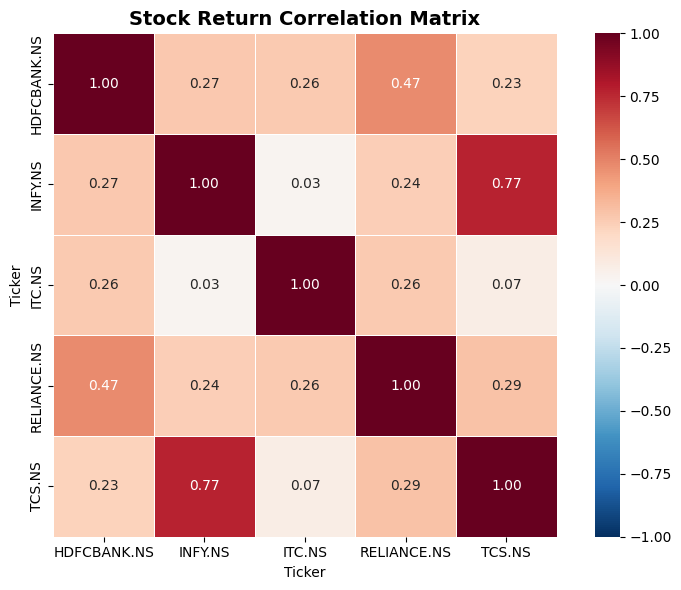


 Chart 4: Normalized Stock Prices (Base = 100)


In [42]:
# ALLOCATION + DRAWDOWN + CORRELATION + PRICE CHARTS


# ─── 1. ALLOCATION PIE CHART ───
print(" Chart 1: Portfolio Allocation")
fig_pie = go.Figure(data=[go.Pie(
    labels=[t.replace('.NS','') for t in weights.keys()],
    values=[w * 100 for w in weights.values()],
    hole=0.4,
    textinfo='label+percent',
)])
fig_pie.update_layout(title='Portfolio Allocation by Stock', template='plotly_dark', height=400)
fig_pie.show()

# ─── 2. DRAWDOWN CHART ───
print("\n Chart 2: Portfolio Drawdown")
cumulative = (1 + portfolio_daily_returns).cumprod()
rolling_max = cumulative.cummax()
drawdown = ((cumulative - rolling_max) / rolling_max) * 100

fig_dd = go.Figure()
fig_dd.add_trace(go.Scatter(
    x=drawdown.index, y=drawdown.values,
    fill='tozeroy', mode='lines', name='Drawdown',
    line=dict(color='#F44336', width=1),
    fillcolor='rgba(244, 67, 54, 0.3)'
))
fig_dd.update_layout(
    title='Portfolio Drawdown (Peak-to-Trough)',
    xaxis_title='Date', yaxis_title='Drawdown (%)',
    template='plotly_dark', height=400
)
fig_dd.show()

max_dd_val = float(drawdown.min())
max_dd_date = drawdown.idxmin()
print(f"    Maximum Drawdown: {max_dd_val:.2f}% on {max_dd_date.date() if hasattr(max_dd_date, 'date') else max_dd_date}")

# ─── 3. CORRELATION HEATMAP ───
print("\n Chart 3: Stock Correlation Matrix")
print("   (Low correlation = better diversification)")
corr = daily_ret.corr()
fig_corr, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Stock Return Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ─── 4. NORMALIZED PRICE CHART ───
print("\n Chart 4: Normalized Stock Prices (Base = 100)")
normalized = prices / prices.iloc[0] * 100
fig_norm = go.Figure()
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']
for i, col in enumerate(normalized.columns):
    fig_norm.add_trace(go.Scatter(
        x=normalized.index, y=normalized[col],
        mode='lines', name=col.replace('.NS',''),
        line=dict(color=colors[i % len(colors)], width=2)
    ))
fig_norm.add_hline(y=100, line_dash="dot", line_color="gray", opacity=0.5)
fig_norm.update_layout(
    title='Individual Stock Performance (Normalized to 100)',
    xaxis_title='Date', yaxis_title='Normalized Price',
    template='plotly_dark', hovermode='x unified', height=500
)
fig_norm.show()

In [43]:
# MARKOWITZ PORTFOLIO OPTIMIZATION


print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 SECTION 6: PORTFOLIO OPTIMIZATION (MARKOWITZ MEAN-VARIANCE)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Theory: Modern Portfolio Theory (Harry Markowitz, 1952)

For a given set of assets, there exists an "efficient frontier" of
portfolios that offer:
  • Maximum return for a given level of risk, OR
  • Minimum risk for a given level of return

We optimize for two objectives:
  1. MAX SHARPE RATIO  → Best risk-adjusted return
  2. MIN VOLATILITY    → Lowest possible risk
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

mean_returns = daily_ret[tickers].mean()
cov_matrix = daily_ret[tickers].cov()
n_assets = len(tickers)
risk_free = 0.07

def portfolio_performance(w):
    """Calculate annualized return and volatility for given weights."""
    ret = float(np.sum(mean_returns.values * w) * 252)
    vol = float(np.sqrt(np.dot(w.T, np.dot(cov_matrix.values * 252, w))))
    return ret, vol

def neg_sharpe(w):
    ret, vol = portfolio_performance(w)
    return -(ret - risk_free) / vol

def min_vol_func(w):
    return portfolio_performance(w)[1]

constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
bounds = tuple((0, 1) for _ in range(n_assets))
init = np.array([1/n_assets] * n_assets)

# Optimize
opt_sharpe = minimize(neg_sharpe, init, method='SLSQP', bounds=bounds, constraints=constraints)
opt_minvol = minimize(min_vol_func, init, method='SLSQP', bounds=bounds, constraints=constraints)

# Results
print(" OPTIMIZATION RESULTS")
print("═" * 60)

for name, result in [(" MAX SHARPE RATIO PORTFOLIO", opt_sharpe), (" MIN VOLATILITY PORTFOLIO", opt_minvol)]:
    ret, vol = portfolio_performance(result.x)
    sharpe = (ret - risk_free) / vol
    print(f"\n{name}:")
    print(f"   Expected Annual Return : {ret*100:.2f}%")
    print(f"   Expected Volatility    : {vol*100:.2f}%")
    print(f"   Sharpe Ratio           : {sharpe:.3f}")
    print(f"   Optimal Weights:")
    for t, w in zip(tickers, result.x):
        if w > 0.001:
            bar = "█" * int(w * 30)
            print(f"      {t.replace('.NS',''):>12}: {w*100:5.1f}%  {bar}")

# Compare with equal weight
eq_ret, eq_vol = portfolio_performance(init)
opt_ret, opt_vol = portfolio_performance(opt_sharpe.x)
print(f"\n OPTIMIZATION IMPACT:")
print(f"   Equal Weight Volatility  : {eq_vol*100:.2f}%")
print(f"   Optimized Volatility     : {opt_vol*100:.2f}%")
print(f"   Volatility Reduction     : {((eq_vol - opt_vol) / eq_vol) * 100:.1f}%")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 SECTION 6: PORTFOLIO OPTIMIZATION (MARKOWITZ MEAN-VARIANCE)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Theory: Modern Portfolio Theory (Harry Markowitz, 1952)

For a given set of assets, there exists an "efficient frontier" of 
portfolios that offer:
  • Maximum return for a given level of risk, OR
  • Minimum risk for a given level of return

We optimize for two objectives:
  1. MAX SHARPE RATIO  → Best risk-adjusted return
  2. MIN VOLATILITY    → Lowest possible risk
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 OPTIMIZATION RESULTS
════════════════════════════════════════════════════════════

 MAX SHARPE RATIO PORTFOLIO:
   Expected Annual Return : 18.85%
   Expected Volatility    : 20.24%
   Sharpe Ratio           : 0.586
   Optimal Weights:
          RELIANCE: 100.0%  █████████████████████████████

 MIN VOLATILITY PORTFOLIO:
   Expected Annual Return :

In [44]:
# EFFICIENT FRONTIER VISUALIZATION


print("Generating Efficient Frontier (5000 random portfolios)...")

np.random.seed(42)
n_portfolios = 5000
all_returns, all_vols, all_sharpes = [], [], []

for _ in range(n_portfolios):
    w = np.random.random(n_assets)
    w /= w.sum()
    ret, vol = portfolio_performance(w)
    all_returns.append(ret * 100)
    all_vols.append(vol * 100)
    all_sharpes.append((ret - risk_free) / vol)

fig_ef = go.Figure()

# Random portfolios
fig_ef.add_trace(go.Scatter(
    x=all_vols, y=all_returns, mode='markers',
    marker=dict(size=3, color=all_sharpes, colorscale='Viridis',
                showscale=True, colorbar=dict(title='Sharpe Ratio')),
    name='Random Portfolios',
    text=[f"Sharpe: {s:.2f}" for s in all_sharpes],
))

# Mark optimal portfolios
for name, result, color, symbol in [
    (" Max Sharpe", opt_sharpe, "red", "star"),
    (" Min Volatility", opt_minvol, "cyan", "diamond")
]:
    ret, vol = portfolio_performance(result.x)
    fig_ef.add_trace(go.Scatter(
        x=[vol*100], y=[ret*100], mode='markers+text',
        marker=dict(size=18, color=color, symbol=symbol,
                    line=dict(width=2, color='white')),
        name=name,
        text=[name], textposition="top center",
        textfont=dict(size=12, color='white')
    ))

fig_ef.update_layout(
    title='Efficient Frontier — 5000 Random Portfolios',
    xaxis_title='Annual Volatility (%)',
    yaxis_title='Expected Annual Return (%)',
    template='plotly_dark', height=550
)
fig_ef.show()

Generating Efficient Frontier (5000 random portfolios)...


 Monthly Returns Heatmap:


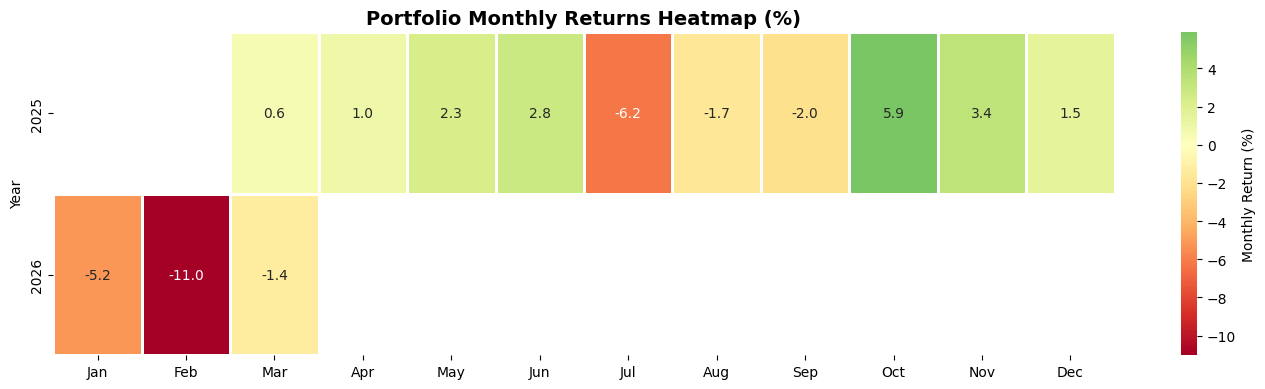


   🟢 Best Month  : October 2025 → +5.9%
   🔴 Worst Month : February 2026 → -11.0%
   📊 Positive Months: 7 / 13


In [45]:
# MONTHLY RETURNS HEATMAP


print(" Monthly Returns Heatmap:")

monthly_ret = portfolio_daily_returns.resample('M').apply(lambda x: (1+x).prod() - 1) * 100
monthly_df = pd.DataFrame({
    'Year': monthly_ret.index.year,
    'Month': monthly_ret.index.month,
    'Return': monthly_ret.values
})

pivot = monthly_df.pivot_table(values='Return', index='Year', columns='Month')
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot.columns = [month_names[m-1] for m in pivot.columns]

fig_heat, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            linewidths=1, ax=ax, cbar_kws={'label': 'Monthly Return (%)'})
ax.set_title('Portfolio Monthly Returns Heatmap (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Year')
plt.tight_layout()
plt.show()

# Quick monthly stats
best_month = monthly_ret.idxmax()
worst_month = monthly_ret.idxmin()
print(f"\n   🟢 Best Month  : {best_month.strftime('%B %Y')} → {float(monthly_ret.max()):+.1f}%")
print(f"   🔴 Worst Month : {worst_month.strftime('%B %Y')} → {float(monthly_ret.min()):+.1f}%")
print(f"   📊 Positive Months: {(monthly_ret > 0).sum()} / {len(monthly_ret)}")

In [46]:

# KEY INSIGHTS (AUTO-GENERATED FROM DATA)


print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 SECTION 7: KEY INSIGHTS & FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

# ─── Calculate all insights automatically ───

# 1. Portfolio vs Benchmark
port_total_return = float((1 + portfolio_daily_returns).prod() - 1) * 100
bench_total_return = float((1 + bench_daily_returns).prod() - 1) * 100
outperformance = port_total_return - bench_total_return

# 2. Best and worst stock
stock_returns = {}
for ticker in tickers:
    ret = float((prices[ticker].iloc[-1] / prices[ticker].iloc[0]) - 1) * 100
    stock_returns[ticker] = ret

best_stock = max(stock_returns, key=stock_returns.get)
worst_stock = min(stock_returns, key=stock_returns.get)

# 3. Max drawdown details
cum = (1 + portfolio_daily_returns).cumprod()
roll_max = cum.cummax()
dd = (cum - roll_max) / roll_max
max_dd_value = float(dd.min()) * 100
max_dd_date = dd.idxmin()

# 4. Correlation analysis
corr_matrix = daily_ret[tickers].corr()

min_corr = 1.0
min_pair = ("", "")
max_corr = -1.0
max_pair = ("", "")

for i in range(len(tickers)):
    for j in range(i+1, len(tickers)):
        c = float(corr_matrix.iloc[i, j])
        if c < min_corr:
            min_corr = c
            min_pair = (tickers[i], tickers[j])
        if c > max_corr:
            max_corr = c
            max_pair = (tickers[i], tickers[j])

# 5. Optimization improvement
eq_ret, eq_vol = portfolio_performance(np.array([1/n_assets] * n_assets))
opt_ret, opt_vol = portfolio_performance(opt_sharpe.x)
vol_reduction = ((eq_vol - opt_vol) / eq_vol) * 100

# 6. Sector contribution
sector_contribution = {}
for ticker in tickers:
    sector = sector_map.get(ticker, "Other")
    s_ret = stock_returns[ticker]
    w = weights[ticker]
    contrib = s_ret * w
    sector_contribution[sector] = sector_contribution.get(sector, 0) + contrib

top_sector = max(sector_contribution, key=sector_contribution.get)

# 7. Risk metrics
sharpe_num = float(metrics["Sharpe Ratio"])
port_vol_num = float(metrics["Annualized Volatility"].replace("%", ""))

# ─── Print All Insights ───
print(f"""
🔍 INSIGHT 1: PORTFOLIO vs BENCHMARK
{'━' * 55}
   • Portfolio Total Return : {port_total_return:+.2f}%
   • Nifty 50 Total Return  : {bench_total_return:+.2f}%
   • Outperformance (Alpha) : {outperformance:+.2f}%
   • Verdict: {"✅ Portfolio BEAT the market!" if outperformance > 0 else "❌ Portfolio underperformed — rebalancing recommended"}

🔍 INSIGHT 2: BEST & WORST PERFORMERS
{'━' * 55}
   • 🟢 Best  : {best_stock.replace('.NS','')} → {stock_returns[best_stock]:+.2f}%
   • 🔴 Worst : {worst_stock.replace('.NS','')} → {stock_returns[worst_stock]:+.2f}%
   • Spread   : {stock_returns[best_stock] - stock_returns[worst_stock]:.2f}%
     (highlights importance of diversification)

🔍 INSIGHT 3: RISK ANALYSIS
{'━' * 55}
   • Maximum Drawdown  : {max_dd_value:.2f}%
   • Occurred on       : {max_dd_date.date() if hasattr(max_dd_date, 'date') else max_dd_date}
   • Annualized Vol    : {port_vol_num:.2f}%
   • Sharpe Ratio      : {sharpe_num:.3f}
   • Assessment: {"🟢 Strong risk-adjusted returns (Sharpe > 1)" if sharpe_num > 1 else "🟡 Moderate risk-adjusted returns (0.5 < Sharpe < 1)" if sharpe_num > 0.5 else "🔴 Weak risk-adjusted returns (Sharpe < 0.5)"}

🔍 INSIGHT 4: DIVERSIFICATION QUALITY
{'━' * 55}
   • Lowest Correlation  : {min_pair[0].replace('.NS','')} & {min_pair[1].replace('.NS','')} → {min_corr:.3f}
     (Best diversification pair — least correlated)
   • Highest Correlation : {max_pair[0].replace('.NS','')} & {max_pair[1].replace('.NS','')} → {max_corr:.3f}
     (Most similar — consider reducing overlap)

🔍 INSIGHT 5: OPTIMIZATION IMPACT
{'━' * 55}
   • Equal Weight Volatility  : {eq_vol*100:.2f}%
   • Optimized Volatility     : {opt_vol*100:.2f}%
   • Risk Reduction           : {vol_reduction:.1f}%
   • Takeaway: Optimization {"significantly reduced" if vol_reduction > 10 else "moderately reduced" if vol_reduction > 5 else "slightly reduced"} risk

🔍 INSIGHT 6: SECTOR CONTRIBUTION TO RETURNS
{'━' * 55}
   • Top Sector: {top_sector}
""")

for sector, contrib in sorted(sector_contribution.items(), key=lambda x: x[1], reverse=True):
    bar = "█" * max(1, int(abs(contrib) * 3))
    sign = "🟢" if contrib >= 0 else "🔴"
    print(f"   {sign} {sector:25s}: {contrib:+.2f}%  {bar}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 SECTION 7: KEY INSIGHTS & FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


🔍 INSIGHT 1: PORTFOLIO vs BENCHMARK
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   • Portfolio Total Return : -10.82%
   • Nifty 50 Total Return  : +10.18%
   • Outperformance (Alpha) : -21.00%
   • Verdict: ❌ Portfolio underperformed — rebalancing recommended

🔍 INSIGHT 2: BEST & WORST PERFORMERS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   • 🟢 Best  : RELIANCE → +17.92%
   • 🔴 Worst : TCS → -25.68%
   • Spread   : 43.60% 
     (highlights importance of diversification)

🔍 INSIGHT 3: RISK ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   • Maximum Drawdown  : -18.69%
   • Occurred on       : 2026-03-05
   • Annualized Vol    : 15.55%
   • Sharpe Ratio      : -1.159
   • Assessment: 🔴 Weak risk-adjusted returns (Sharpe < 0.5)

🔍 INSIGHT 4: DIVERSIFICATION QUALITY


In [47]:

# EXECUTIVE SUMMARY


# Prepare optimal weights string
opt_weights_str = ""
for t, w in zip(tickers, opt_sharpe.x):
    if w > 0.01:
        opt_weights_str += f"      {t.replace('.NS',''):>12}: {w*100:.1f}%\n"

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║                    📋 EXECUTIVE SUMMARY                              ║
╚══════════════════════════════════════════════════════════════════════╝

━━━ PORTFOLIO OVERVIEW ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   • Stocks Held        : {len(tickers)} large-cap Indian equities
   • Sectors Covered    : {len(set(sector_map.values()))} (IT, Energy, Banking, FMCG)
   • Total Invested     : ₹{total_invested:,.0f}
   • Current Value      : ₹{total_current:,.0f}
   • Total P&L          : ₹{float(total_pnl):,.0f} ({float(total_pnl_pct):+.2f}%)
   • Analysis Period    : {prices.index[0].date()} to {prices.index[-1].date()}

━━━ PERFORMANCE vs BENCHMARK ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   • Portfolio Return   : {port_total_return:+.2f}%
   • Nifty 50 Return    : {bench_total_return:+.2f}%
   • Alpha Generated    : {outperformance:+.2f}%
   • Sharpe Ratio       : {metrics['Sharpe Ratio']}
   • Sortino Ratio      : {metrics['Sortino Ratio']}
   • Maximum Drawdown   : {metrics['Max Drawdown']}
   • Beta               : {metrics.get('Beta', 'N/A')}
   • Value at Risk (95%): {metrics['VaR (95%)']}

━━━ OPTIMIZATION RECOMMENDATION ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Markowitz Mean-Variance optimizer recommends:

{opt_weights_str}
   Optimized Portfolio Metrics:
   • Expected Return    : {opt_ret*100:.2f}%
   • Expected Volatility: {opt_vol*100:.2f}%
   • Risk Reduction vs Equal Weight: {vol_reduction:.1f}%

━━━ KEY TAKEAWAYS ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   1. {"✅ Portfolio outperformed Nifty 50 — active stock selection added value" if outperformance > 0 else "❌ Portfolio underperformed — rebalancing to optimized weights recommended"}

   2. 🟢 Best Performer: {best_stock.replace('.NS','')} ({stock_returns[best_stock]:+.2f}%)
      🔴 Worst Performer: {worst_stock.replace('.NS','')} ({stock_returns[worst_stock]:+.2f}%)

   3. Best diversification: {min_pair[0].replace('.NS','')} & {min_pair[1].replace('.NS','')}
      (correlation: {min_corr:.3f}) — least correlated pair

   4. Optimization reduces portfolio risk by {vol_reduction:.1f}% through
      better weight allocation using Markowitz efficient frontier

   5. Daily VaR: {metrics['VaR (95%)']} at 95% confidence — on any given day,
      there is a 5% chance of losing more than this amount

━━━ TOOLS & TECHNIQUES ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   • Data Source     : Yahoo Finance API (yfinance)
   • Risk Metrics    : Sharpe, Sortino, VaR, CVaR, Beta, Alpha, Drawdown
   • Optimization    : Markowitz Mean-Variance (scipy.optimize)
   • Visualization   : Plotly (interactive), Seaborn, Matplotlib
   • Theory Applied  : Modern Portfolio Theory, CAPM, Efficient Frontier

━━━ FUTURE ENHANCEMENTS ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   • Add sector rotation strategy based on macro indicators
   • Implement Black-Litterman model for views-based optimization
   • Add options overlay analysis for hedging strategies
   • Real-time Streamlit dashboard deployment

══════════════════════════════════════════════════════════════════════════════════
Built by Prince Raj | IIT Jodhpur | B.Tech 
══════════════════════════════════════════════════════════════════════════════════
""")

print("\n PROJECT COMPLETE! ")


╔══════════════════════════════════════════════════════════════════════╗
║                    📋 EXECUTIVE SUMMARY                              ║
╚══════════════════════════════════════════════════════════════════════╝

━━━ PORTFOLIO OVERVIEW ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   • Stocks Held        : 5 large-cap Indian equities
   • Sectors Covered    : 4 (IT, Energy, Banking, FMCG)
   • Total Invested     : ₹90,200
   • Current Value      : ₹59,159
   • Total P&L          : ₹-31,041 (-34.41%)
   • Analysis Period    : 2025-03-05 to 2026-03-05

━━━ PERFORMANCE vs BENCHMARK ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   • Portfolio Return   : -10.82%
   • Nifty 50 Return    : +10.18%
   • Alpha Generated    : -21.00%
   • Sharpe Ratio       : -1.159
   • Sortino Ratio      : -1.757
   • Maximum Drawdown   : -18.69%
   • Beta               : 0.989
   • Value at Risk (95%): -1.41%

━━━ OPTIMIZATION RECOMMENDATION ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Markowitz Mean-Variance op